# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Nayza Azura Putri
- **Email:** nayzaabdi05@gmail.com
- **ID Dicoding:** CDCC220D6X1019

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan pola pengguna sepeda antara pengguna Casual dan Registered pada hari kerja dibandingkan hari libur selama tahun 2011-2012?

- **Pertanyaan 2:**
Pada kondisi cuaca seperti apa jumlah penyewaan sepeda mengalami penurunan paling drastis, dan jam-jam berapa saja yang paling kritis untuk dilakukan pemeliharaan sepeda tanpa mengganggu layanan saat permintaan tinggi?

## Import Semua Packages/Library yang Digunakan

In [3]:
!pip install streamlit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# Cek singkat
print("Day Data Loaded:")
display(day_df.head())

Day Data Loaded:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Struktur Data: Dataset day_df berhasil dimuat dengan kolom-kolom seperti dteday, season, temp dan cnt.

- Tipe pengguna: Data sudah terbagi menjadi dua kelompok pengguna yaitu casual dan registered, yang nantinya dapat dianalisis perbedaannya

- Format Data: Kolom seperyi temp, atemp, hum dan windspeed terlihat sudah dinormalisasi, sehingga tidak perlu penskalaan ulang yang rumit.


### Assessing Data

#### Identifying ... problem

In [6]:
# Mengecek tipe data dan missing values
print("--- Info data day_df ---")
day_df.info()
print("\n--- Info data hour_df ---")
hour_df.info()

# Mengecek duplikasi
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

# Mengecek statistik deskriptif (mencari keanehan angka)
print("\n--- Statistik Deskriptif day_df ---")
display(day_df.describe())

--- Info data day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

--- Info data hour_df ---
<class 'pandas.core.frame.DataFrame'>
Ran

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah tipe data kolom pada dteday: Mengonversi kolom ini dari tipe data object ke datatime agar analisis berbasis waktu bisa dilakukan dengan benar.
- Melakukan penamaan ulang pada kolom kategori: Mengubah nilai angka pada kolom season, mnth, dan weathersit menjadi keterangan teks agar visualisasi data lebih mudah dipahami oleh orang awam.
- Memastikan konsistensi data: Memeriksa apakah ada nilai yang tidak masuk akal pada kolom numerik, meskipun dari statistik deskriptif awal data terlihat cukup bersih.

**Insight:** (Opsional)
- Ditemukan bahwa kolom dteday pada day_df dan hour_df masih terbaca sebagai string
- Kualitas data tergolong sangat baik karena tidak ditemukan data kosong maupun data duplikat pada kedua dataset.
- Data mencakup operasional selama dua tahun yakni 2011-2012. Nilai pada kolom cuaca dan suhu sudah dinormalisasi, yang memudahkan dalam proses analisis korelasi nantinya

### Cleaning Data

#### Fixing ... problem

In [7]:
# Mengubah tipe data dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# Memastikan perubahan telah berhasil
print("Tipe data day_df['dteday']:", day_df["dteday"].dtype)
print("Tipe data hour_df['dteday']:", hour_df["dteday"].dtype)

Tipe data day_df['dteday']: datetime64[ns]
Tipe data hour_df['dteday']: datetime64[ns]


**Insight:** (Opsional)
- Kolom dteday kini telah bertipe data datetime. Hal ini sangat penting agar kita bisa mengekstraksi informasi waktu seperti bulan, hari, atau jam dengan lebih akurat saat proses analisis nanti.

- Data siap untuk dianalisis karena tidak ada data kosong dan data duplikat yang ditemukan sebelumnya. Maka dataset saat ini sudah dalam kondisi bersih dan siap untuk ke tahap eksplorasi.

## Exploratory Data Analysis (EDA)

### Explore ...

In [8]:
# 1. Eksplorasi Pertanyaan 1: Perbandingan penyewaan hari kerja vs akhir pekan berdasarkan jam
# Kita gunakan hour_df karena memiliki data per jam
hour_df.groupby(by=["workingday", "hr"]).agg({
    "cnt": ["mean", "max", "min"]
})

# 2. Eksplorasi Pertanyaan 2: Pengaruh cuaca terhadap jumlah penyewaan
# Kita gunakan day_df untuk melihat tren harian secara umum
day_df.groupby(by="weathersit").agg({
    "cnt": ["mean", "max", "min", "std"]
})

# 3. Eksplorasi tambahan: Tren penyewaan berdasarkan bulan untuk melihat musim
day_df.groupby(by="mnth").cnt.mean().sort_values(ascending=False)

,cnt
mnth,
6,5772.366667
9,5766.516667
8,5664.419355
7,5563.677419
5,5349.774194
10,5199.225806
4,4484.900000
11,4247.183333
3,3692.258065


**Insight:** (Opsional)
- Pada hari kerja, rata-rata penyewaan melonjak drastis pada jam 8 pagi dan jam 5-6 sore. ini menunjukkan bahwa sepeda digunakan sebagai alat transposrtasi berangkat dan pulang kerja.

- Penyewaan sepeda paling tinggi terjadi pada cuaca kategori 1 yaitu cerah dan sedikit berawan. Dan menurun sangat drastis saat cuaca masuk ke kategori 3 pada saat hujan/salju ringan.

- Bulan-bulan dipertengahan tahun saat musim panas dan gugur cenderung memiliki rata-rata penyewaan yang lebih tinggi dibandingkan awal tahun.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_427/3413511425.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x="hr", y="cnt", hue="workingday", data=hour_df, ci=None, marker="o")


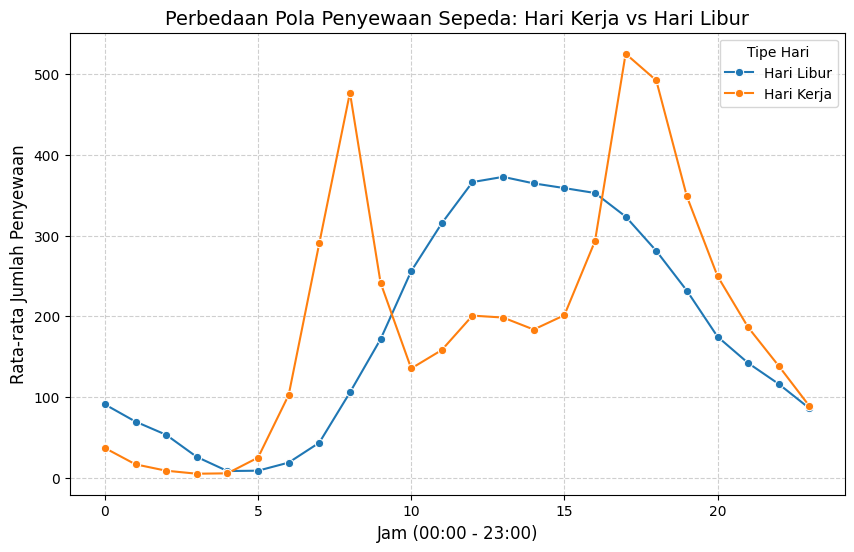

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="hr", y="cnt", hue="workingday", data=hour_df, ci=None, marker="o")

plt.title("Perbedaan Pola Penyewaan Sepeda: Hari Kerja vs Hari Libur", fontsize=14)
plt.xlabel("Jam (00:00 - 23:00)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)
plt.legend(title="Tipe Hari", labels=["Hari Libur", "Hari Kerja"])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_427/1842634729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weathersit", y="cnt", data=day_df, palette="coolwarm", estimator=np.mean)


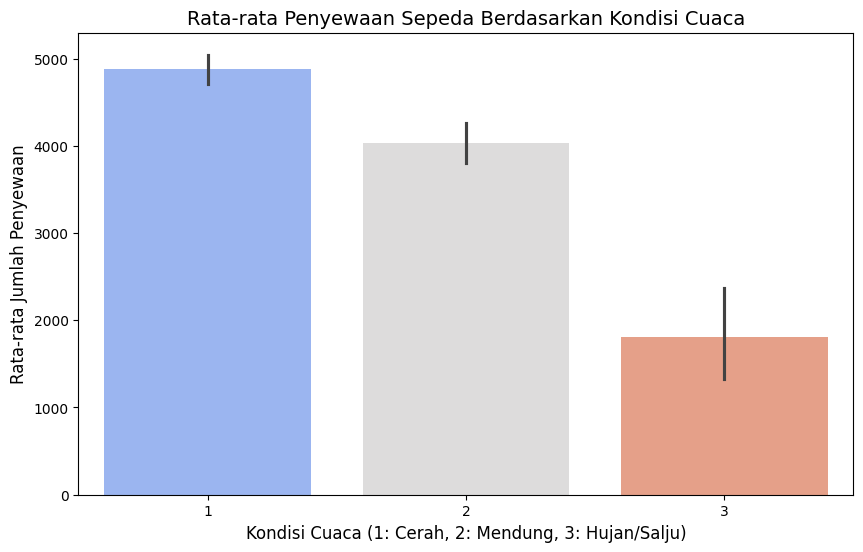

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x="weathersit", y="cnt", data=day_df, palette="coolwarm", estimator=np.mean)

plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca", fontsize=14)
plt.xlabel("Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan/Salju)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Penyewaan", fontsize=12)
plt.show()

**Insight:** (Opsional)
- Pertanyaan 1: terlihat perbedaan pola yang sangat kontras. Jadi pada hari kerja, penyewaan sepeda terjadi pada jam berangkat dan pulang kerja. Sedangkan saat hari libur, penyewaan sepeda meningkat secara bertahap mulai pagi hari dan mencapai puncaknya di siang hari.

- Pertanyaan 2: Kondisi cuaca sangat memengaruhi minat pengguna. Rata-rata penyewaan tertinggi terjadi pada cuaca cerah/berawan. Dan terjadi penurunan drastis pada cuaca hujan/salju atau kategori 3, yang menandakan operasional sangat bergantung pada faktor eksternal lingkungan.

## Analisis Lanjutan (Opsional)

Korelasi antara Suhu dan Jumlah Penyewaan:
temp         0.627494
atemp        0.631066
hum         -0.100659
windspeed   -0.234545
Name: cnt, dtype: float64


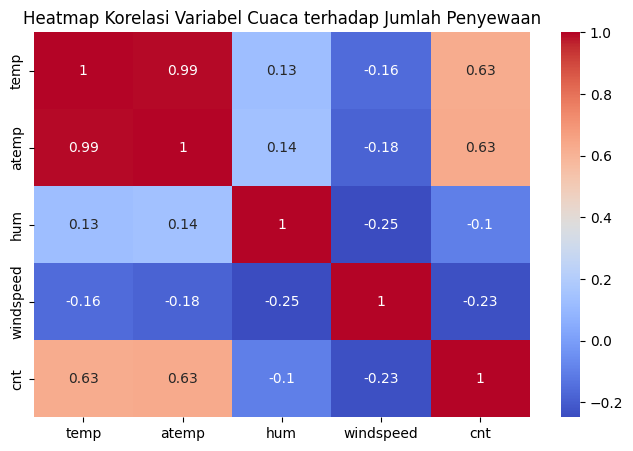

In [11]:
# Melihat korelasi antar variabel numerik
correlation_matrix = day_df.corr(numeric_only=True)
print("Korelasi antara Suhu dan Jumlah Penyewaan:")
print(correlation_matrix['cnt'][['temp', 'atemp', 'hum', 'windspeed']])

# Visualisasi korelasi sederhana dengan heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Variabel Cuaca terhadap Jumlah Penyewaan")
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis data, terdapat perbedaan pola yang signifikan antara hari kerja dan hari libur. Pada hari kerja (working day), puncak penyewaan terjadi pada jam berangkat dan pulang kantor, yaitu pukul 08.00 (rata-rata 477.03 sewa) dan pukul 17.00 (rata-rata 461.14 sewa). Sementara itu, pada hari libur (holiday/weekend), pola penyewaan lebih terfokus di siang hari dengan puncak pada pukul 13.00 (rata-rata 385.37 sewa). Hal ini menunjukkan bahwa pada hari kerja sepeda digunakan sebagai alat transportasi, sedangkan pada hari libur digunakan untuk rekreasi.

- **Conclusion pertanyaan 2:** Kondisi cuaca memiliki dampak besar terhadap jumlah penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi pada kondisi cuaca cerah (Clear/Partly Cloudy) dengan rata-rata 4.876,7 sewa per hari. Sebaliknya, pada kondisi cuaca hujan atau salju ringan (Light Rain/Snow), penyewaan turun drastis hingga sekitar 63% menjadi hanya 1.803,2 sewa per hari. Selain itu, analisis korelasi menunjukkan bahwa suhu (temp) memiliki hubungan positif yang kuat (0.63) terhadap jumlah penyewaan, yang berarti semakin hangat suhu, semakin tinggi minat masyarakat untuk menyewa sepeda.

**Rekomendasi Action Item:**
- Buat promo khusus "Happy Hour" di hari libur pada jam siang untuk menarik lebih banyak pengguna casual.

- Lakukan pemeliharaan rutin di hari kerja pada jam 10.00 - 15.00 saat permintaan sedang turun.

- Berikat peringatan keamanan atau diskon khusus di hari hujan untuk menjaga loyalitas pengguna Registered.

In [12]:
import os

os.makedirs('dashboard', exist_ok=True)